In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()

/tmp/ipykernel_3597800/2605779135.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


In [3]:
v = rdf.group_by("model", "resampled").agg(pl.len()).sort("len", descending=True).collect()
for row in v.iter_rows(named=True):
    print(f"{row['model']} - {row['resampled']}: {row['len']}")

polar-angle-mr-hydra - False: 640
drcif - False: 640
difference-mr-hydra - False: 640
u-rstsf - False: 640
loky-stacker-v5-r1 - False: 640
polar-magnitude-mr-hydra - False: 640
rank-mr-hydra - False: 640
scale-mr-hydra - False: 640
downsample-mr-hydra - False: 640
rdst - False: 640
mr-hydra - False: 640
quant - False: 640
rstsf - False: 640
stacker-v4-r1 - False: 640
cumsum-mr-hydra - False: 640
catch22 - False: 640
hivecotev2 - False: 588
fast-stacker-v4-r1 - False: 159
fast-stacker-v5-r1 - False: 84
quant-catboost - False: 65
fast-stacker-v5-r3 - False: 56
stacker-v4-r3 - False: 23
mr-hydra - True: 3
loky-stacker-v5-r1 - True: 2


In [4]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")
    .filter(pl.col("model") != "difference-mr-hydra")
    .filter(pl.col("model") != "scale-mr-hydra")
    .filter(pl.col("model") != "cumsum-mr-hydra")
    .filter(pl.col("model") != "downsample-mr-hydra")
    .filter(pl.col("model") != "rank-mr-hydra")
    .filter(pl.col("model") != "polar-magnitude-mr-hydra")
    .filter(pl.col("model") != "polar-angle-mr-hydra")
    .filter(pl.col("model") != "catch22")
    #.filter(pl.col("model") != "drcif")
    #.filter(pl.col("model") != "fast-stacker-v5-r3")
    #.filter(pl.col("model") != "quant-catboost")
    .filter(pl.col("model") != "fast-stacker-v4-r1")
    .filter(pl.col("model") != "fast-stacker-v5-r1")
    .filter(pl.col("model") != "fast-stacker-v5-r3")

).collect(engine="streaming").filter(pl.col("resampled") == False)
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""OSULeaf""","""hivecotev2""",100,false,0.96281
"""InsectWingbeatSound""","""drcif""",400,false,0.632828
"""Trace""","""u-rstsf""",400,false,1.0
"""TwoLeadECG""","""drcif""",500,false,0.982441
"""GesturePebbleZ2""","""stacker-v4-r1""",300,false,0.879747
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [5]:
rdf.collect()['model'].unique()

model
str
"""quant"""
"""polar-angle-mr-hydra"""
"""rank-mr-hydra"""
"""fast-stacker-v4-r1"""
"""cumsum-mr-hydra"""
…
"""stacker-v4-r3"""
"""quant-catboost"""
"""polar-magnitude-mr-hydra"""


In [6]:
from aeon.visualisation import plot_critical_difference

In [7]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,loky-stacker-v5-r1,quant,rdst,rstsf,quant-catboost
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""OSULeaf""",0.965909,0.803306,0.773554,0.980165,0.968595,0.980165,0.879339,0.981818,0.867769,0.853306
"""Trace""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""TwoLeadECG""",0.999122,0.985953,0.964004,0.997717,0.998244,0.997893,0.996488,0.997717,0.990518,0.992098
"""FaceFour""",0.988636,0.970455,0.945455,0.997727,0.947727,0.995455,0.975,0.988636,0.995455,0.977273
"""DodgerLoopDay""",0.615584,0.566234,0.662338,0.638961,0.581818,0.633766,0.672727,0.65974,0.638961,0.623377
…,…,…,…,…,…,…,…,…,…,…
"""Computers""",0.7632,0.736,0.7664,0.7856,0.7752,0.7872,0.792,0.7608,0.74,0.784
"""ProximalPhalanxOutlineCorrect""",0.895189,0.893471,0.90378,0.921649,0.919588,0.922337,0.907904,0.886598,0.913402,0.890034
"""PLAID""",0.896462,0.902793,0.916201,0.955307,0.941899,0.956425,0.945624,0.936685,0.891993,0.918063


(<Figure size 600x290 with 1 Axes>, <Axes: >)

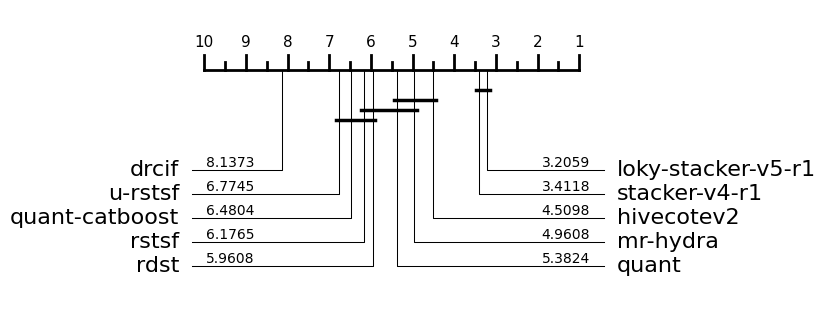

In [8]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [9]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [10]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,loky-stacker-v5-r1,quant,rdst,rstsf,quant-catboost,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""BirdChicken""",0.9,0.95,0.91,0.9,0.9,0.9,0.9,0.9,0.95,0.9,20,20,2,512
"""TwoLeadECG""",0.999122,0.985953,0.964004,0.997717,0.998244,0.997893,0.996488,0.997717,0.990518,0.992098,23,1139,2,82
"""FaceFour""",0.988636,0.970455,0.945455,0.997727,0.947727,0.995455,0.975,0.988636,0.995455,0.977273,24,88,4,350
"""FreezerSmallTrain""",0.999123,0.999088,0.965263,0.998386,0.994316,0.998386,0.998947,0.994877,0.996561,0.998596,28,2850,2,301
"""CinCECGTorso""",0.999638,0.995797,0.947536,0.994493,0.973333,0.994638,0.994058,0.991884,0.974638,1.0,40,1380,4,1639
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""UWaveGestureLibraryY""",0.777778,0.748967,0.76622,0.810999,0.808208,0.810999,0.770966,0.764098,0.751982,0.775544,896,3582,8,315
"""MelbournePedestrian""",0.94075,0.968693,0.974041,0.97818,0.968693,0.978266,0.976024,0.965589,0.972833,0.97542,1138,2319,10,24
"""NonInvasiveFetalECGThorax1""",0.949211,0.911349,0.917863,0.960407,0.959695,0.960407,0.936285,0.929669,0.925496,0.945038,1800,1965,42,750


20


(<Figure size 600x290 with 1 Axes>, <Axes: >)

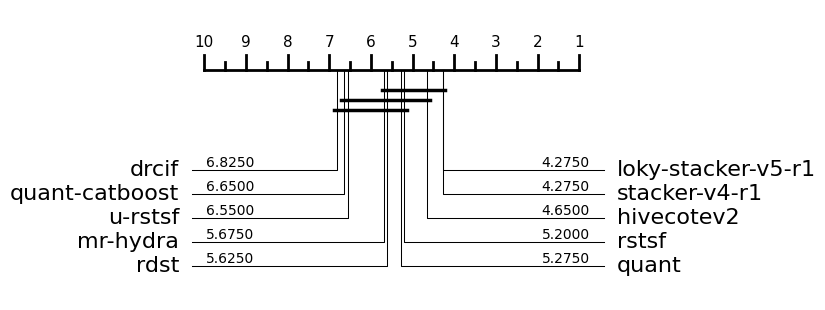

In [11]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

22


(<Figure size 600x290 with 1 Axes>, <Axes: >)

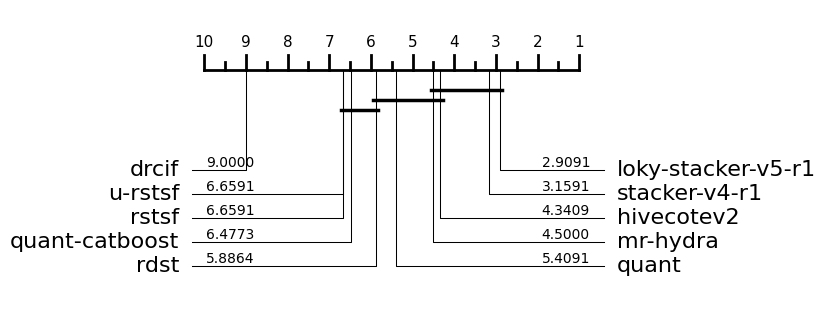

In [12]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

9


(<Figure size 600x290 with 1 Axes>, <Axes: >)

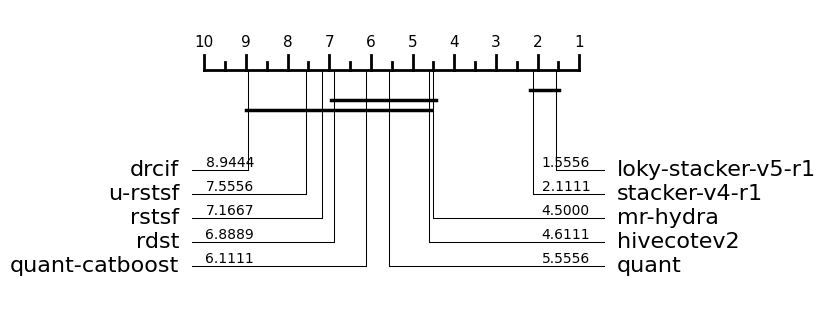

In [13]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [14]:
rdf.collect().pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('downsample-mr-hydra')

dataset,polar-angle-mr-hydra,hivecotev2,downsample-mr-hydra,drcif,scale-mr-hydra,polar-magnitude-mr-hydra,catch22,u-rstsf,stacker-v4-r1,cumsum-mr-hydra,mr-hydra,rank-mr-hydra,fast-stacker-v5-r1,loky-stacker-v5-r1,stacker-v4-r3,quant,fast-stacker-v5-r3,fast-stacker-v4-r1,rdst,rstsf,difference-mr-hydra,quant-catboost
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.288502,0.391878,0.327954,0.356224,0.349895,0.354008,0.305802,0.38903,0.349895,0.269093,0.349895,0.34557,null,0.349895,null,0.382278,null,null,0.337975,0.380907,0.369831,null
"""InlineSkate""",0.436727,0.533182,0.464364,0.502182,0.496727,0.497455,0.434182,0.623636,0.586545,0.431273,0.497091,0.469818,0.584545,0.582909,null,0.586909,0.598182,0.569091,0.447273,0.601818,0.475273,0.534545
"""ScreenType""",0.488533,0.556267,0.511467,0.529067,0.529067,0.5392,0.501867,0.5504,0.546133,0.48,0.5472,0.495467,0.549333,0.5488,null,0.5328,null,0.557333,0.5216,0.522133,0.5344,0.553333
"""MiddlePhalanxOutlineAgeGroup""",0.527273,0.575325,0.515584,0.574026,0.580519,0.544156,0.6,0.603896,0.580519,0.579221,0.59632,0.579221,null,0.585714,null,0.61039,null,0.581169,0.584416,0.597403,0.535065,0.623377
"""RefrigerationDevices""",0.589333,0.552,0.521067,0.592533,0.528,0.524267,0.507733,0.5824,0.577067,0.506133,0.526933,0.5472,0.562667,0.5744,null,0.581867,null,null,0.5568,0.5904,0.538667,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",0.996825,1.0,1.0,1.0,0.996825,1.0,1.0,1.0,1.0,0.989841,1.0,0.979683,1.0,1.0,null,1.0,null,1.0,1.0,1.0,1.0,null
"""TwoPatterns""",0.99195,1.0,1.0,0.99425,1.0,0.30035,0.8436,0.992,1.0,0.9977,1.0,0.99975,1.0,1.0,1.0,0.99995,null,1.0,1.0,0.99645,0.9932,null
"""GunPointMaleVersusFemale""",0.996835,1.0,1.0,0.999367,1.0,1.0,0.990506,1.0,1.0,0.996835,1.0,0.982278,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.996835,0.984177


In [15]:
import ray
ray.shutdown()

In [16]:
df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('loky-stacker-v5-r1')

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,loky-stacker-v5-r1,quant,rdst,rstsf,quant-catboost
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.391878,0.356224,0.38903,0.349895,0.349895,0.349895,0.382278,0.337975,0.380907,null
"""GestureMidAirD3""",0.570769,0.492308,0.450769,0.46,0.516923,0.463077,0.503077,0.516923,0.46,null
"""ScreenType""",0.556267,0.529067,0.5504,0.546133,0.5472,0.5488,0.5328,0.5216,0.522133,0.553333
"""EOGVerticalSignal""",0.554144,0.525414,0.548619,0.550276,0.512155,0.550276,0.544199,0.546961,0.532597,null
"""Haptics""",0.553247,0.481818,0.513636,0.562987,0.515584,0.564935,0.518831,0.577922,0.513636,null
…,…,…,…,…,…,…,…,…,…,…
"""ShapeletSim""",1.0,0.92,0.963333,1.0,1.0,1.0,0.983333,1.0,0.968889,null
"""Plane""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""InsectEPGRegularTrain""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,null


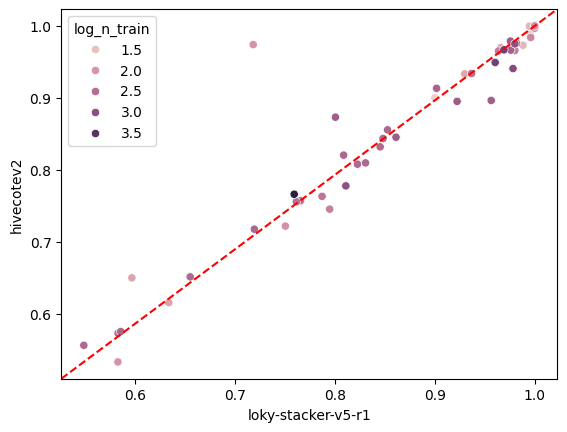

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = joined.to_pandas()
plot_df["log_n_train"] = np.log10(plot_df["n_train"])

sns.scatterplot(data=plot_df, x='loky-stacker-v5-r1', y='hivecotev2', hue='log_n_train')
#plt.scatter(joined['loky-stacker-v5-r1'], joined['hivecotev2'])
#plt.xlabel('loky-stacker-v5-r1')
#plt.ylabel('hivecotev2')
# add x=y line 
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color='red', linestyle='--')

In [18]:
v

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,loky-stacker-v5-r1,quant,rdst,rstsf,quant-catboost
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""OSULeaf""",0.965909,0.803306,0.773554,0.980165,0.968595,0.980165,0.879339,0.981818,0.867769,0.853306
"""Trace""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""TwoLeadECG""",0.999122,0.985953,0.964004,0.997717,0.998244,0.997893,0.996488,0.997717,0.990518,0.992098
"""FaceFour""",0.988636,0.970455,0.945455,0.997727,0.947727,0.995455,0.975,0.988636,0.995455,0.977273
"""DodgerLoopDay""",0.615584,0.566234,0.662338,0.638961,0.581818,0.633766,0.672727,0.65974,0.638961,0.623377
…,…,…,…,…,…,…,…,…,…,…
"""Computers""",0.7632,0.736,0.7664,0.7856,0.7752,0.7872,0.792,0.7608,0.74,0.784
"""ProximalPhalanxOutlineCorrect""",0.895189,0.893471,0.90378,0.921649,0.919588,0.922337,0.907904,0.886598,0.913402,0.890034
"""PLAID""",0.896462,0.902793,0.916201,0.955307,0.941899,0.956425,0.945624,0.936685,0.891993,0.918063
